# Projet 05 - Deep Learning & Vision : encadrer et nommer les poissons de l'aquarium

*Temps estimé : 60 minutes*

*Difficulté : 6/10* -> Si tu rencontres des difficultés, c'est donc NORMAL ! -> Je te montrerai tout dans la correction :)

**IMPORTANT** Si ta machine peine (moins de 16 GB de RAM, CPU un peu ancien), importe ce code sur Google Colab comme nous l'avons vu pour le précédent projet. L'entraînement dure environ 5 minutes sur un CPU de portable récent.

Let's Go :)

<div align="center">
<img src="./image.png" alt="ouvrir dans VSCode pour voir l'image" width="800"/>
</div>

Cette semaine, tu te rends à l'aquarium de la ville avec ta nièce. Elle adooore les poissons, et te pose tout pleins de questions :

« Et lui, c'est quoi ? »

« Et celui-là, à côté ? »

« Et celui la avec les rayures ?»

Si seulement tu étais aussi bon en vie sous-marine qu'en Data Science ! ahah !

Tu décides alors de développer un algorithme pour te permettre de prendre une photo, repérer s'il y a un poisson dessus, et identifier celui-ci

On y va !

### L'outil du jour : Faster R-CNN

Dans ce projet, nous allons prendre un modèle de vision par ordinateur pré-entraîné, observer ce qu'il sait déjà faire, puis le fine-tuner sur nos 13 espèces.

Le modèle qu'on utilise s'appelle **Faster R-CNN** : il repère d'abord des centaines de régions "qui ressemblent à un objet" (le *Region Proposal Network*), puis classifie et affine chacune de ces régions.

Faster R-CNN a la réputation d'être lourd. torchvision propose heureusement une version bien plus légère, `fasterrcnn_mobilenet_v3_large_320_fpn` : le même principe, mais avec le MobileNetV3 comme squelette et une résolution interne réduite (320 pixels), pensée pour la vitesse. De quoi fine-tuner sur un simple CPU de portable, sans carte graphique.

**Un mot avant de commencer.** C'est le premier projet du cahier où tu vas réellement entraîner un réseau de neurones : jusqu'ici, scikit-learn et Hugging Face faisaient le travail derrière un `.fit()` ou un `pipeline()`. Ici, tu vas ouvrir le capot, préparer les données toi-même, geler une partie du réseau, écrire la boucle d'entraînement. C'est plus long à lire, et c'est normal de ne pas tout absorber du premier coup.

### uv add : des librairies de plus

```bash
uv add torchvision kagglehub torchmetrics
```

`torchvision` apporte les modèles de vision et leurs poids pré-entraînés, `kagglehub` télécharge le dataset, et `torchmetrics` fournit le **mAP**, la métrique standard de la détection (on la laisse de côté dans le fil principal, elle t'attend dans *Pour aller plus loin*).

Le fichier `utils.py` s'occupe cette semaine de toute la plomberie autour des données (lire les fichiers d'annotation, construire le tableau des photos) et de tous les affichages, pour qu'on puisse se concentrer sur le Deep Learning. Jette-lui un oeil si tu es curieux, mais rien de ce qu'il contient n'est nouveau pour toi.

In [1]:
import os
import random

import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.io import read_image
from torchvision.transforms import v2 as T
import torchvision.transforms.v2.functional as F
from torchvision.models.detection import (
    fasterrcnn_mobilenet_v3_large_320_fpn,
    FasterRCNN_MobileNet_V3_Large_320_FPN_Weights,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

import kagglehub

from utils import (SPECIES, build_fish_dataframe, collate_fn, compute_map, label_path_for,
                   list_images, plot_boxes, plot_ground_truth_grid, plot_loss_curves,
                   plot_species_counts, read_yolo_boxes)

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

# Partie 1 - Les poissons (et leurs boîtes) de Kaggle

Voici le dataset pour cette semaine : [`fish-dataset`](https://www.kaggle.com/datasets/mahmoodyousaf/fish-dataset) : plus de 8 200 photos de 13 espèces de poissons d'aquarium, réparties en trois lots (entraînement, validation, test), au format YOLO.

In [2]:
# Télécharge le dataset (environ 350 Mo, une seule fois : les exécutions suivantes réutilisent le cache local)
DATASET_DIR = kagglehub.dataset_download("mahmoodyousaf/fish-dataset", output_dir="data")

print("Dataset téléchargé dans :", DATASET_DIR)

100%|██████████| 342M/342M [01:03<00:00, 5.64MB/s] 

Extracting files...


Dataset téléchargé dans : data


Chaque photo a un fichier de labels associé (un `.txt` dans `data/train/labels`), avec une ligne par poisson : `classe x_centre y_centre largeur hauteur`, ces quatre derniers nombres étant exprimés en fraction de la largeur/hauteur de l'image (entre 0 et 1). L'indice de classe pointe vers la liste `SPECIES`.

Décoder ce format n'a rien de bien passionnant : `utils.py` s'en charge avec `read_yolo_boxes` (qui convertit une ligne YOLO en rectangle `[x1, y1, x2, y2]` en pixels) et `build_fish_dataframe` (qui parcourt les trois lots et construit un tableau d'une ligne par photo, avec son espèce dominante).

13 espèces : AngelFish, BlueTang, ButterflyFish, ClownFish, GoldFish, Gourami, MorishIdol, PlatyFish, RibbonedSweetlips, ThreeStripedDamselfish, YellowCichlid, YellowTang, ZebraFish


,image_path,species,split
0,data\train\images\001_jpg.rf.d47e7ce0fd847e561...,ButterflyFish,train
1,data\train\images\001_jpg.rf.eaa7c989ec5ef785a...,ButterflyFish,train
2,data\train\images\002_jpg.rf.130be8cea6916f0b2...,ButterflyFish,train
3,data\train\images\002_jpg.rf.2f5deb4bb969ad624...,ButterflyFish,train
4,data\train\images\002_jpg.rf.3468dfbec49bbe101...,ButterflyFish,train


7750 photos étiquetées au total


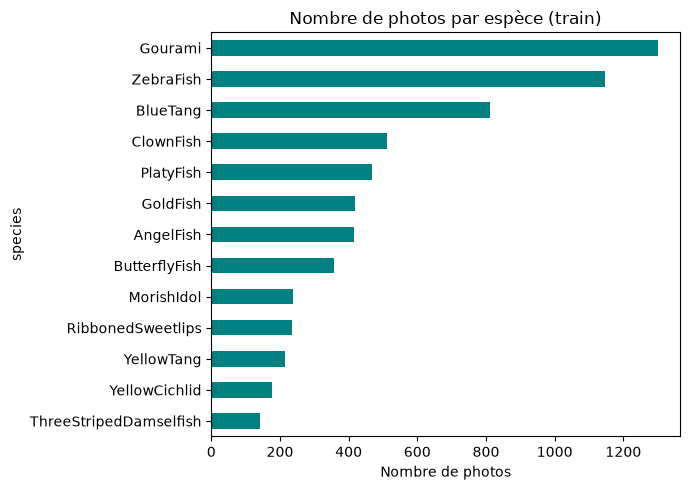

species
Gourami                   1300
ZebraFish                 1148
BlueTang                   812
ClownFish                  512
PlatyFish                  468
GoldFish                   418
AngelFish                  416
ButterflyFish              356
MorishIdol                 238
RibbonedSweetlips          234
YellowTang                 214
YellowCichlid              176
ThreeStripedDamselfish     142
Name: count, dtype: int64

In [3]:
print(f"{len(SPECIES)} espèces : {', '.join(SPECIES)}")

fish_df = build_fish_dataframe(DATASET_DIR)
display(fish_df.head())
print(f"{len(fish_df)} photos étiquetées au total")

plot_species_counts(fish_df, split="train")

La répartition est loin d'être uniforme : un Gourami a presque 10 fois plus de photos qu'un YellowCichlid. On garde ça en tête, et on avance.

Un tableau de coordonnées, ça ne parle pas beaucoup : dessinons plutôt les vraies boîtes sur six photos d'entraînement tirées au hasard.

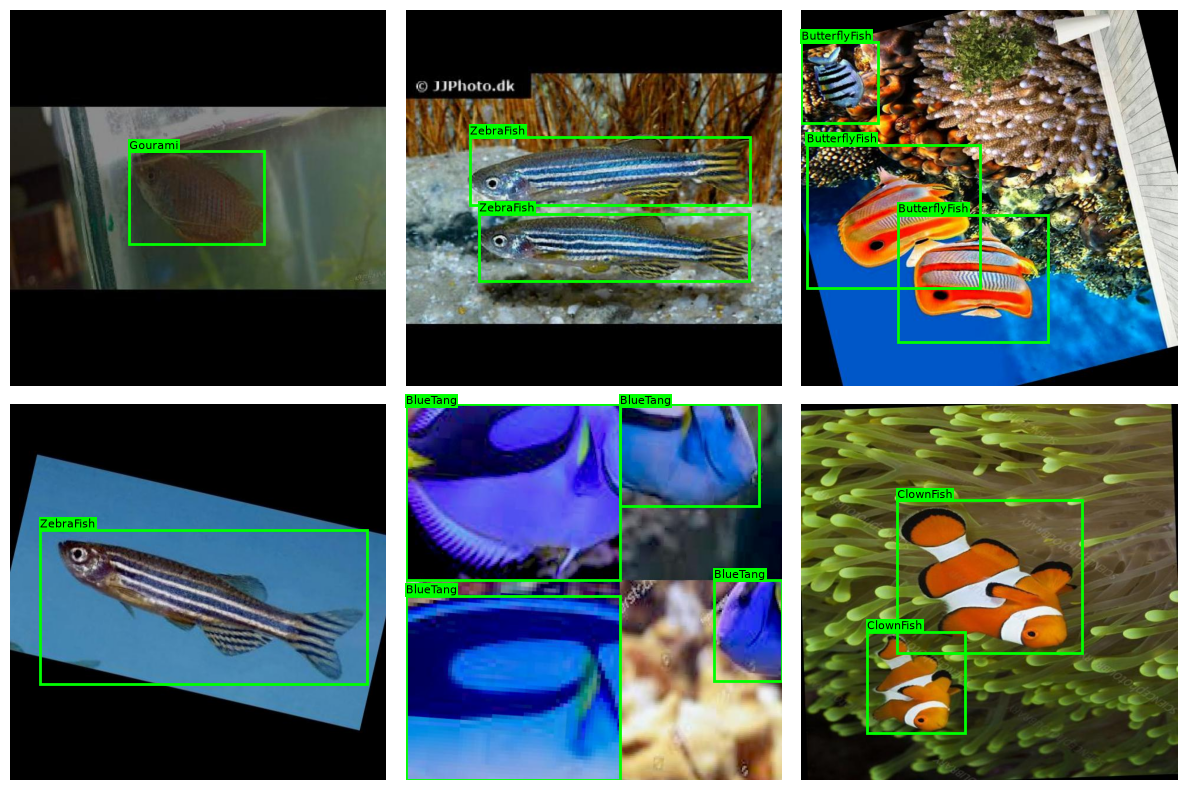

In [4]:
sample_paths = fish_df[fish_df["split"] == "train"]["image_path"].sample(n=6, random_state=SEED).tolist()
plot_ground_truth_grid(sample_paths)

# Partie 2 - Le détecteur pré-entraîné

Le modèle `fasterrcnn_mobilenet_v3_large_320_fpn` est pré-entraîné sur **COCO**, un jeu de données de référence en détection d'objets (personnes, voitures, animaux domestiques, mobilier...), avec 91 catégories. Chargeons-le, et testons-le tel quel sur nos poissons.

In [5]:
weights = FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT

coco_model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=weights).eval()  # le détecteur pré-entraîné, en évaluation
coco_categories = weights.meta["categories"]                               # les 91 catégories COCO

print(f"Faster R-CNN (MobileNetV3) chargé : {sum(p.numel() for p in coco_model.parameters()):,} paramètres")
print("Catégories COCO contenant 'fish' :", [c for c in coco_categories if "fish" in c.lower()] or "AUCUNE")

Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to C:\Users\smazo/.cache\torch\hub\checkpoints\fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:16<00:00, 4.63MB/s]


Faster R-CNN (MobileNetV3) chargé : 19,386,354 paramètres
Catégories COCO contenant 'fish' : AUCUNE


Sans surprise : COCO ne contient tout simplement aucune catégorie poisson. Voyons ce que le modèle propose quand même.

### Étape 1 : faire prédire un détecteur

Complete la fonction `predict` : elle prend un modèle et le chemin d'une image, fait tourner le détecteur, et ne garde que les boîtes dont le score de confiance dépasse `score_thresh`. C'est LA mécanique d'inférence en détection : tu la réutiliseras telle quelle à la fin du projet, avec ton modèle fine-tuné.

Quatre étapes :
1. charge l'image avec `read_image(image_path)[:3]` (le `[:3]` élimine un éventuel canal alpha), convertis-la en float normalisé avec `F.to_dtype(image, torch.float32, scale=True)`, puis ajoute une dimension de batch avec `.unsqueeze(0)`
2. passe ce batch dans le modèle (à l'intérieur du `with torch.no_grad():`) : il retourne une **liste** d'un seul dictionnaire (`"boxes"`, `"labels"`, `"scores"`), garde l'élément `[0]`
3. construis un masque booléen `keep` : les scores strictement supérieurs à `score_thresh`
4. filtre `"boxes"`, `"labels"` et `"scores"` avec ce masque, et traduis les indices de labels en noms avec `names`

> Indice : un tensor PyTorch se filtre directement avec un masque booléen, comme un tableau numpy (`tensor[mask]`). `.tolist()` convertit un tensor en liste Python.

In [ ]:
def predict(model, image_path, names, score_thresh=0.5):
    """
    Run a detection model on an image and keep the detections above score_thresh.

    Arguments:
    model -- a torchvision detection model, in eval mode
    image_path -- path to an image file, of any resolution
    names -- list of category names, indexed by the label indices the model outputs
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of category names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    ### START CODE HERE ###
    
    batch =  F.to_dtype(read_image(image_path)[:3], torch.float32, scale = True).unsqueeze(0) # (1) image -> float [0,1] -> batch de 1
    with torch.no_grad():
        output =   # (2) une seule image envoyée : on garde le premier (et unique) résultat
    keep =   # (3) masque booléen des détections assez confiantes
    boxes =  # (4) on filtre les 3 tensors avec le même masque
    labels = 
    scores = 

    ### END CODE HERE ###

    return boxes, labels, scores


goldfish_path = os.path.join(DATASET_DIR, "train", "images",
                             "batch_1_34_goldfish_16_jpg.rf.631bf82a6ed6e4ea66637d3ca6b6dae7.jpg")
boxes, labels, scores = predict(coco_model, goldfish_path, coco_categories)
plot_boxes(Image.open(goldfish_path).convert("RGB"), boxes, labels, scores, box_color="orange",
           title="Détecteur brut (COCO) - vraie espèce : GoldFish")

print(f"{len(boxes)} détection(s) : {list(zip(labels, [round(s, 2) for s in scores]))}")
assert isinstance(boxes, list) and isinstance(labels, list) and isinstance(scores, list), \
    "boxes, labels et scores doivent être des listes"
assert len(boxes) == len(labels) == len(scores), "les trois listes doivent avoir la même longueur"
print("Exercice validé !")

Édifiant : sur un poisson rouge photographié de très près, le modèle voit... un "bird" (oiseau) ! Une deuxième photo pour confirmer :

In [ ]:
clownfish_path = os.path.join(DATASET_DIR, "train", "images",
                              "CLOWN-PERCULA-CLASSIC-AQUACULTURED-PAIR-Amphiprion-percula_jpg.rf.2d0bece80bf5100491a22972fee01a23.jpg")

boxes, labels, scores = predict(coco_model, clownfish_path, coco_categories, score_thresh=0.3)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, box_color="orange",
           title="Détecteur brut (COCO) - vraie espèce : ClownFish")

Même verdict pour le poisson-clown. COCO n'a purement et simplement jamais entendu parler de poissons, ni en tant que concept général, ni a fortiori en espèces. Le modèle localise pourtant plutôt bien la zone intéressante de l'image (le Region Proposal Network sait repérer "un objet"), il se trompe seulement sur ce que c'est. C'est encourageant : la moitié du travail (localiser) est déjà là, il reste à lui apprendre le reste (classifier correctement).

Petit bonus au passage : ce détecteur accepte des images de **taille variable**, il les redimensionne lui-même en interne et rescale les boîtes de sortie dans le repère de l'image d'origine. Une photo de téléphone en 4032 x 3024 peut lui être donnée telle quelle, sans aucun préprocessing manuel de notre part.

# Partie 3 - Servir les données au modèle

On a les photos. On a les boîtes, déjà décodées en pixels par `read_yolo_boxes`. Il reste à les **servir** au modèle... et c'est moins évident qu'il n'y paraît.

L'entraînement va poser des milliers de fois la même question : *donne-moi l'échantillon numéro 3812*. À chaque fois, trois choses doivent se produire :

1. **ouvrir la photo** : on ne charge pas 6800 images en mémoire, on les lit une par une, au dernier moment
2. **mettre les boîtes en tensors** : elles existent, mais sous forme de nombres dans un fichier texte ; le modèle, lui, ne mange que des tensors PyTorch
3. **emballer le tout** dans la structure exacte que torchvision attend

C'est exactement le rôle d'un objet **`Dataset`** en PyTorch. Attention au faux ami : ce n'est pas un stock de données. **C'est une recette pour fabriquer l'échantillon numéro `i` à la demande.** Deux méthodes suffisent à la définir : `__len__` (combien y en a-t-il ?) et `__getitem__` (donne-moi le numéro `i`).

Le **`DataLoader`** se sert ensuite de cette recette : il tire des indices au hasard, réclame les échantillons correspondants, et les regroupe en batchs pour la boucle d'entraînement.

C'est ta première rencontre avec ces deux objets, et ils reviendront dans tous tes projets PyTorch. Je te donne le code en entier : lis-le, il ne contient que trois idées.

In [ ]:
basic_transform = T.Compose([T.ToDtype(torch.float32, scale=True)])  # pas d'augmentation pour l'instant


class FishDetectionDataset(Dataset):
    def __init__(self, image_paths, transforms=None):
        self.image_paths = image_paths
        self.transforms = transforms

    def __len__(self):
        """Combien d'échantillons en tout ? Le DataLoader a besoin de le savoir."""
        return len(self.image_paths)

    def __getitem__(self, i):
        """Fabrique l'échantillon numéro i : une image, et tout ce qu'on sait d'elle."""
        image_path = self.image_paths[i]
        image = read_image(image_path)[:3]                                    # la photo, en tensor (3, H, W)
        H, W = image.shape[-2:]
        boxes, class_indices = read_yolo_boxes(label_path_for(image_path), W, H)

        # IDÉE 1 : les boîtes deviennent un tensor de forme (nombre de poissons, 4)
        boxes_t = torch.tensor(boxes, dtype=torch.float32).reshape(-1, 4)

        # IDÉE 2 : +1 sur chaque espèce. torchvision réserve la classe 0 au "fond"
        # (l'absence d'objet), donc nos 13 espèces occupent les indices 1 à 13.
        # dtype=torch.int64 est obligatoire : sur une photo sans poisson, la liste est
        # vide et torch.tensor([]) fabriquerait des float, que le modèle refuse.
        labels_t = torch.tensor([c + 1 for c in class_indices], dtype=torch.int64)

        # IDÉE 3 : on emballe dans tv_tensors. C'est ce qui permettra plus tard à une
        # rotation ou un miroir de déplacer les boîtes EN MÊME TEMPS que l'image.
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes_t, format="XYXY", canvas_size=(H, W)),
            "labels": labels_t,
        }
        image = tv_tensors.Image(image)

        if self.transforms:
            image, target = self.transforms(image, target)

        return image, target


# Regardons ce que fabrique la recette, sur une photo qu'on connaît déjà
demo_image, demo_target = FishDetectionDataset([clownfish_path], transforms=basic_transform)[0]

print(f"image  : tensor {tuple(demo_image.shape)}, valeurs entre {demo_image.min():.2f} et {demo_image.max():.2f}")
print(f"boîtes : {demo_target['boxes'].shape[0]} poisson(s), coordonnées {demo_target['boxes'].tolist()}")
print(f"labels : {demo_target['labels'].tolist()}  ->  {[SPECIES[i - 1] for i in demo_target['labels'].tolist()]}")

Voilà à quoi ressemble **un** échantillon : une image, et un dictionnaire `target` qui contient toutes ses boîtes et toutes leurs espèces. C'est ce couple, et rien d'autre, que le modèle va recevoir des milliers de fois.

Une dernière subtilité avant d'assembler les lots. D'un échantillon à l'autre, les images n'ont pas la même taille et ne contiennent pas le même nombre de poissons : impossible de les empiler dans un seul gros tensor, comme on le ferait en classification. C'est le rôle de `collate_fn` (fournie dans `utils.py`) : elle garde simplement des **listes**. Le détecteur, lui, sait très bien traiter une liste d'images de tailles différentes.

`MAX_TRAIN_IMAGES` limite le nombre de photos d'entraînement pour rester rapide sur un ordinateur portable : avec 1000 photos et 3 epochs, compte environ 5 minutes sur un CPU récent. Augmente ces valeurs si ta machine tient la charge, ou passe sur Google Colab.

In [ ]:
MAX_TRAIN_IMAGES = 1000
MAX_VAL_IMAGES = 300
BATCH_SIZE = 4        # Réduire si manque de mémoire

all_train, all_val = list_images(DATASET_DIR, "train"), list_images(DATASET_DIR, "valid")
train_images = random.sample(all_train, min(MAX_TRAIN_IMAGES, len(all_train)))
val_images = random.sample(all_val, min(MAX_VAL_IMAGES, len(all_val)))

train_loader = DataLoader(FishDetectionDataset(train_images, transforms=basic_transform),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FishDetectionDataset(val_images, transforms=basic_transform),
                        batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

images, targets = next(iter(train_loader))
print(f"Un batch = {len(images)} images de tailles {[tuple(im.shape[-2:]) for im in images]}")
print(f"            et {[len(t['labels']) for t in targets]} poisson(s) respectivement")
print()
print(f"Entraînement : {len(train_images)} photos, {len(train_loader)} batchs de {BATCH_SIZE}")
print(f"Validation   : {len(val_images)} photos, {len(val_loader)} batchs de {BATCH_SIZE}")

# Partie 4 - Le fine-tuning

Les données sont pretes, on arrive enfin a la derniere partie : celle du fine-tuning (l'affinage du modele existant sur les nouvelles données)

La logique : geler le corps du réseau (`model.backbone`), et n'entraîner vraiment que la tête de classification des boîtes (`model.roi_heads.box_predictor`).

### Étape 1 : adapter le modèle

Complète `build_model` :
1. gèle tous les paramètres de `model.backbone`, en passant leur attribut `requires_grad` à `False`
2. remplace `model.roi_heads.box_predictor` par un nouveau `FastRCNNPredictor(in_features, num_classes_with_background)`, où `in_features = model.roi_heads.box_predictor.cls_score.in_features` (le nombre d'entrées de la couche actuelle)

> Indice : `num_classes_with_background` vaut 14 dans notre cas (13 espèces + le fond).

In [ ]:
def build_model(num_classes_with_background):
    """
    Load a pretrained Faster R-CNN (MobileNetV3 backbone) and adapt it to a new number of classes.

    Arguments:
    num_classes_with_background -- number of species to detect, PLUS the background class

    Returns:
    model -- the adapted model, with a frozen backbone and a new box-classification head
    """
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights=FasterRCNN_MobileNet_V3_Large_320_FPN_Weights.DEFAULT)

    ### START CODE HERE ###

    for p in model.backbone.parameters():
          # (1) on gèle le backbone : il sait déjà "voir"
    in_features =   # (2) la taille d'entrée de l'ancienne tête
    model.roi_heads.box_predictor =  # (3) la nouvelle tête

    ### END CODE HERE ###

    return model


model = build_model(len(SPECIES) + 1)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{n_trainable:,} paramètres entraînables sur {sum(p.numel() for p in model.parameters()):,} au total")

assert model.roi_heads.box_predictor.cls_score.out_features == 14, "14 sorties attendues (13 espèces + fond)"
assert all(not p.requires_grad for p in model.backbone.parameters()), "model.backbone devrait être gelé"
print("Exercice validé !")

### Étape 2 : la boucle d'entraînement

Contrairement a une tache de classification, en mode entraînement (`model.train()`), le fait d'appeler `model(images, targets)` **ne retourne pas des prédictions**, mais un dictionnaire de 4 losses (`loss_classifier`, `loss_box_reg`, `loss_objectness`, `loss_rpn_box_reg`), une par sous-partie du réseau. On les additionne pour obtenir la loss totale à rétropropager.

Complète la boucle :
1. calcule `loss_dict = model(images, targets)` (les deux sont déjà des listes, grâce à `collate_fn`)
2. calcule la loss totale : `loss = sum(loss_dict.values())`
3. remets les gradients à zéro avec `optimizer.zero_grad()`, rétropropage avec `loss.backward()`, puis mets à jour les poids avec `optimizer.step()`

C'est parti pour environ 10-30 minutes de calcul, selon ta machine: le bon moment pour aller te chercher un café.

In [ ]:
NUM_EPOCHS = 3  # Réduire si trop lent
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=5e-4)

loss_names = ["loss_classifier", "loss_box_reg", "loss_objectness", "loss_rpn_box_reg"]
loss_history = {name: [] for name in loss_names}

for epoch in range(NUM_EPOCHS):
    model.train()
    running = {name: 0.0 for name in loss_names}
    n_batches = 0
    for images, targets in train_loader:
        images, targets = list(images), list(targets)

        ### START CODE HERE ###

        loss_dict =  # (1) en mode train(), retourne un dict de 4 losses
        loss =   # (2) la loss totale à rétropropager
        # (3) on remet les gradients à zéro...
        # (4) ...on rétropropage...
        # (5) ...et on met à jour les poids

        ### END CODE HERE ###

        for name in loss_names:
            running[name] += loss_dict[name].item()
        n_batches += 1

    for name in loss_names:
        loss_history[name].append(running[name] / n_batches)
    print(f"epoch {epoch + 1}/{NUM_EPOCHS}  loss totale {sum(loss_history[name][-1] for name in loss_names):.3f}")

assert sum(loss_history[name][-1] for name in loss_names) < sum(loss_history[name][0] for name in loss_names), \
    "La loss totale devrait diminuer entre la première et la dernière epoch"
print("Exercice validé !")

In [ ]:
plot_loss_curves(loss_history, NUM_EPOCHS)

`loss_classifier` et `loss_box_reg` (est-ce le bon poisson, et la boîte est-elle bien placée) sont en général celles qui baissent le plus, car ce sont les seules parties du réseau vraiment concernées par NOS 13 espèces. `loss_objectness` et `loss_rpn_box_reg` viennent du Region Proposal Network, qui savait déjà repérer "un objet" grâce à son pré-entraînement COCO, et n'a donc pas grand-chose de nouveau à apprendre.

# Partie 5 - Le détecteur fine-tuné à l'oeuvre

Nous y sommes !

Nous pouvons maintenant utiliser notre modele ! Pour cela, il suffit d'appeler la fonction `predict` de l'Étape 1 avec le modèle fine-tuné, et avec la liste de noms qui correspond à SES sorties.

**Attention à l'indice** : en Partie 3, le `Dataset` a décalé nos espèces de +1 pour laisser la classe 0 au fond. La liste de noms à passer commence donc par le fond, puis les 13 espèces : un label de sortie `1` désignera bien `SPECIES[0]`.

> Indice : `names = ["fond"] + SPECIES`, puis `predict(model, image_path, names, score_thresh)`. N'oublie pas `model.eval()` avant de prédire : plus question de calculer des gradients, seulement de prédire.

In [ ]:
model.eval()


def identifier_et_encadrer_poissons(image_path, score_thresh=0.5):
    """
    Detect and identify every fish in a photo, using the fine-tuned model.

    Arguments:
    image_path -- path to an image file, of any resolution
    score_thresh -- minimum confidence score to keep a detection

    Returns:
    boxes -- list of [x1, y1, x2, y2] pixel boxes
    labels -- list of species names, same order as boxes
    scores -- list of confidence scores, same order as boxes
    """

    ### START CODE HERE ###

    names =  # (1) la classe 0 est le fond, nos espèces suivent : label 1 -> SPECIES[0]
    boxes, labels, scores =   # (2) l'Étape 1, avec le modèle fine-tuné

    ### END CODE HERE ###

    return boxes, labels, scores


boxes, labels, scores = identifier_et_encadrer_poissons(clownfish_path)
plot_boxes(Image.open(clownfish_path).convert("RGB"), boxes, labels, scores, title="Identification")

print(f"{len(boxes)} détection(s) : {list(zip(labels, [round(s, 2) for s in scores]))}")
assert all(label in SPECIES for label in labels), \
    f"Toutes les étiquettes doivent être des espèces (attention au décalage du fond), tu obtiens {labels}"
print("Exercice validé !")

Essaie maintenant avec tes propres photos : dépose une image dans le dossier du projet, et appelle `identifier_et_encadrer_poissons("mon_fichier.jpg")`. N'importe quelle résolution fait l'affaire, y compris une photo de téléphone brute : le modèle se charge du redimensionnement.

**Remarque** : le modèle ne connaît que les 13 espèces apprises : sur un poisson d'une autre espèce, il détectera probablement quelque chose (un objet, une forme), mais lui collera l'étiquette de l'espèce la plus ressemblante parmi les 13, sans jamais dire « je ne connais pas cette espèce ».

---

# Bilan

Résumons les points clés de ce projet :

1. **Détecter, ce n'est pas classer.** Une photo d'aquarium ne se résume pas à une seule étiquette : il faut répondre à deux questions pour chaque poisson présent — où est-il, et qu'est-ce que c'est.
2. **Le détecteur pré-entraîné brut** (COCO) ne connaissait aucune catégorie poisson : il confondait nos espèces avec des oiseaux, tout en localisant pourtant correctement la zone intéressante de l'image.
3. **Le `Dataset` et le `DataLoader`** sont la courroie entre tes fichiers et le réseau : une recette qui fabrique l'échantillon `i` à la demande, et un distributeur qui la sollicite en boucle. Tu les retrouveras dans tous tes projets PyTorch.
4. **Le fine-tuning**, en gelant le backbone et en ne remplaçant que la tête de classification des boîtes, a suffi à obtenir un détecteur fonctionnel en quelques minutes de calcul CPU, sans même de data augmentation.

Quelques limites : l'absence de data augmentation, le dataset déséquilibré, le `MAX_TRAIN_IMAGES` volontairement restreint, et aucune espèce ne peut être signalée comme "inconnue". Les espèces les plus rares du dataset fournissent en plus très peu d'exemples de boîtes au réseau, et souffrent davantage que les espèces populaires.

Ta nièce peut enfin balayer l'aquarium entier du regard : chaque poisson, encadré, nommé.

### Pour aller plus loin

Quelques idées à explorer :

- **mesurer** ton détecteur au lieu de le juger à l'oeil : `compute_map(model, val_loader)` (la fonction t'attend dans `utils.py`) calcule le **mAP**, la métrique standard de la détection. Elle compare les boîtes prédites aux vraies à plusieurs seuils de recouvrement, et moyenne sur les 13 espèces
- entraîner sur les 6800 photos complètes et plus d'epochs (idéalement sur Google Colab avec un GPU), et comparer le mAP obtenu
- essayer `fasterrcnn_resnet50_fpn`, la version "grande" de Faster R-CNN (plus lente, mais souvent plus précise), et comparer
- le dataset est nativement au format YOLO : la librairie `ultralytics` entraîne un vrai YOLO en quelques lignes (`yolo detect train data=data.yaml model=yolo11n.pt`), une baseline intéressante à comparer à ce Faster R-CNN
- ajouter de la data augmentation boîtes comprises (`torchvision.transforms.v2` + `tv_tensors` : `RandomHorizontalFlip`, `RandomPhotometricDistort`, `RandomZoomOut`...) et regarder si le mAP progresse vraiment sur ce dataset
- construire une vraie application avec `streamlit`, avec la caméra du téléphone en entrée directe